In [2]:
import sys
from pathlib import Path

# Add parent directory to path so we can import utils and withProperties
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import DataLoader, TensorDataset

from utils.preprocessing import FEATURES, normalize_label_name, preprocess_data, balance_dataset
from utils.models import CNNLSTM
from withProperties.properties import Property, LowBytesProperty, LowPacketsProperty, PropertyCollection
from withProperties.experiment_logger import ExperimentConfig, PropertyConfig, ExperimentLogger

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

DATASET_CSV_PATH = "../data/CICIoT2023/ciciot2023_labeled_conn.tsv"
# DATASET_CSV_PATH = "../data/CICIDS2017/wednesday_labeled.tsv"

Device: cuda


In [5]:
cleaned_df = preprocess_data(DATASET_CSV_PATH)
print(cleaned_df.shape)
print(cleaned_df["label"].value_counts())

(1850844, 8)
label
DOS_HTTP_FLOOD    1508589
BENIGN             342255
Name: count, dtype: int64


In [6]:
cleaned_df = cleaned_df[cleaned_df["label"].isin(["BENIGN", "DOS_HTTP_FLOOD"])].copy()
print(cleaned_df["label"].value_counts())

label
DOS_HTTP_FLOOD    1508589
BENIGN             342255
Name: count, dtype: int64


In [7]:
X = cleaned_df[FEATURES]
y = cleaned_df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=42,
)

print("Train label distribution (before balancing):")
print(y_train.value_counts())
print("\nTest label distribution:")
print(y_test.value_counts())

Train label distribution (before balancing):
label
DOS_HTTP_FLOOD    1056012
BENIGN             239578
Name: count, dtype: int64

Test label distribution:
label
DOS_HTTP_FLOOD    452577
BENIGN            102677
Name: count, dtype: int64


In [8]:
X_train_balanced, y_train_balanced = balance_dataset(X_train, y_train)

print(y_train_balanced.value_counts())

label
BENIGN            239578
DOS_HTTP_FLOOD    239578
Name: count, dtype: int64


In [9]:
X_train_balanced, y_train_balanced = balance_dataset(X_train, y_train)

print(y_train_balanced.value_counts())

label
BENIGN            239578
DOS_HTTP_FLOOD    239578
Name: count, dtype: int64


In [10]:
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train_balanced)
y_test_enc = label_encoder.transform(y_test)

# Encode categorical features
X_train_balanced = X_train_balanced.copy()
X_test = X_test.copy()

categorical_cols = X_train_balanced.select_dtypes(include=["str"]).columns
ordinal_encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
X_train_balanced[categorical_cols] = ordinal_encoder.fit_transform(X_train_balanced[categorical_cols])
X_test[categorical_cols] = ordinal_encoder.transform(X_test[categorical_cols])

print("Categorical columns:", list(categorical_cols))
X_train_balanced.head()

Categorical columns: ['duration', 'orig_bytes', 'resp_bytes', 'proto', 'conn_state']


,duration,orig_bytes,resp_bytes,orig_pkts,resp_pkts,proto,conn_state
0,134669.0,12660.0,2124.0,14,13,1.0,10.0
1,0.0,0.0,0.0,1,0,2.0,6.0
2,0.0,0.0,0.0,1,0,2.0,6.0
3,282165.0,12455.0,1.0,2,0,2.0,6.0
4,278675.0,9192.0,495.0,9,6,1.0,2.0


In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_balanced[FEATURES])
X_test_scaled = scaler.transform(X_test[FEATURES])

print("Classes:", label_encoder.classes_)

Classes: ['BENIGN' 'DOS_HTTP_FLOOD']


In [12]:
# CNNLSTM expects input shape: (N, 1, F)
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).unsqueeze(1)

# BCEWithLogitsLoss expects float targets 0/1
y_train_tensor = torch.tensor(y_train_enc, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_enc, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1024, shuffle=False)

print(X_train_tensor.shape, y_train_tensor.shape)
print(X_test_tensor.shape, y_test_tensor.shape)

torch.Size([479156, 1, 7]) torch.Size([479156])
torch.Size([555254, 1, 7]) torch.Size([555254])


In [13]:
model = CNNLSTM(n_features=len(FEATURES)).to(device)
print(model)

CNNLSTM(
  (conv): Sequential(
    (0): Conv1d(1, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (5): ReLU()
    (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (lstm): LSTM(128, 64, batch_first=True)
  (head): Sequential(
    (0): Dropout(p=0.3, inplace=False)
    (1): Linear(in_features=64, out_features=64, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [14]:
feat_idx = {col: i for i, col in enumerate(FEATURES)}

orig_bytes_idx = feat_idx["orig_bytes"]
orig_pkts_idx = feat_idx["orig_pkts"]

# DOS_HTTP_FLOOD should map to class 1 if label_encoder.classes_ is ['BENIGN', 'DOS_HTTP_FLOOD']
dos_idx = np.where(label_encoder.classes_ == "DOS_HTTP_FLOOD")[0][0]
print("DOS class index:", dos_idx)

theta_orig_bytes = 100.0
theta_orig_pkts = 2.0

orig_bytes_thr_scaled = (theta_orig_bytes - scaler.mean_[orig_bytes_idx]) / scaler.scale_[orig_bytes_idx]
orig_pkts_thr_scaled = (theta_orig_pkts - scaler.mean_[orig_pkts_idx]) / scaler.scale_[orig_pkts_idx]

# Create property objects
low_bytes_prop = LowBytesProperty(
    name="LowBytes",
    feature_name="orig_bytes",
    feature_idx=orig_bytes_idx,
    theta=theta_orig_bytes,
    theta_scaled=orig_bytes_thr_scaled,
)

low_pkts_prop = LowPacketsProperty(
    name="LowPackets",
    feature_name="orig_pkts",
    feature_idx=orig_pkts_idx,
    theta=theta_orig_pkts,
    theta_scaled=orig_pkts_thr_scaled,
)

# Create property collection
properties = PropertyCollection([low_bytes_prop, low_pkts_prop])
print(properties)

DOS class index: 1
PropertyCollection[
  LowBytes(feature=orig_bytes, idx=1, theta=100.0)
  LowPackets(feature=orig_pkts, idx=3, theta=2.0)
]


In [15]:
# Initialize experiment logger
property_configs = [
    PropertyConfig(
        name=low_bytes_prop.name,
        feature_name=low_bytes_prop.feature_name,
        feature_idx=low_bytes_prop.feature_idx,
        theta=low_bytes_prop.theta,
        theta_scaled=low_bytes_prop.theta_scaled,
    ),
    PropertyConfig(
        name=low_pkts_prop.name,
        feature_name=low_pkts_prop.feature_name,
        feature_idx=low_pkts_prop.feature_idx,
        theta=low_pkts_prop.theta,
        theta_scaled=low_pkts_prop.theta_scaled,
    ),
]

config = ExperimentConfig(
    dataset_path=DATASET_CSV_PATH,
    num_features=len(FEATURES),
    features=FEATURES,
    num_samples=len(cleaned_df),
    num_train_samples=len(X_train_balanced),
    num_test_samples=len(X_test),
    label_distribution=y_train_balanced.value_counts().to_dict(),
    properties=property_configs,
    lambda_prop=0.5,  # Will be set below, but declare here
    learning_rate=1e-3,
    batch_size=256,
    num_epochs=10,
    test_size=0.3,
    description="CNNLSTM with property-based constraints",
)

logger = ExperimentLogger(config, base_dir="../experiments")


Experiment: 20260403_231021_2props
Saving to: ..\experiments\20260403_231021_2props


In [16]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()

lambda_prop = 0.5
num_epochs = 10

for epoch in range(num_epochs):
    model.train()

    pred_losses = []
    prop_losses = []
    epoch_stats = {}

    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)          # (N, 1, F)
        y_batch = y_batch.to(device)          # (N,)

        optimizer.zero_grad()

        logits = model(x_batch)               # (N,)
        pred_loss = criterion(logits, y_batch)

        p_dos = torch.sigmoid(logits)         # Probability of DOS_HTTP_FLOOD
        prop_loss, stats = properties.compute_loss(model, x_batch, p_dos)

        loss = pred_loss + lambda_prop * prop_loss
        loss.backward()
        optimizer.step()

        pred_losses.append(pred_loss.item())
        prop_losses.append(prop_loss.item())
        epoch_stats = stats

    avg_pred_loss = np.mean(pred_losses)
    avg_prop_loss = np.mean(prop_losses)
    
    print(
        f"Epoch {epoch+1:02d} | "
        f"pred_loss={avg_pred_loss:.4f} | "
        f"prop_loss={avg_prop_loss:.4f}"
    )
    print(epoch_stats)
    
    # Log epoch metrics
    logger.log_epoch(epoch, avg_pred_loss, avg_prop_loss, epoch_stats)

Epoch 01 | pred_loss=0.1058 | prop_loss=0.0472
{'antecedent': 0.26254600286483765, 'p_dos': 0.48918288946151733, 'LowBytes': 0.28567662835121155, 'LowPackets': 0.49284085631370544}
Epoch 02 | pred_loss=0.0932 | prop_loss=0.0466
{'antecedent': 0.26193368434906006, 'p_dos': 0.48447707295417786, 'LowBytes': 0.285997599363327, 'LowPackets': 0.49293437600135803}
Epoch 03 | pred_loss=0.0898 | prop_loss=0.0466
{'antecedent': 0.2836463451385498, 'p_dos': 0.5574818849563599, 'LowBytes': 0.30912652611732483, 'LowPackets': 0.4917026162147522}
Epoch 04 | pred_loss=0.0876 | prop_loss=0.0467
{'antecedent': 0.25454890727996826, 'p_dos': 0.49424707889556885, 'LowBytes': 0.27833276987075806, 'LowPackets': 0.4928196370601654}
Epoch 05 | pred_loss=0.0856 | prop_loss=0.0467
{'antecedent': 0.2997390031814575, 'p_dos': 0.5436908602714539, 'LowBytes': 0.3268294036388397, 'LowPackets': 0.4968689978122711}
Epoch 06 | pred_loss=0.0853 | prop_loss=0.0467
{'antecedent': 0.3118925392627716, 'p_dos': 0.560076653957

In [17]:
model.eval()
all_preds = []
all_true = []

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)

        logits = model(x_batch)
        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).long().cpu().numpy()

        all_preds.extend(preds)
        all_true.extend(y_batch.numpy().astype(int))

y_true_labels = label_encoder.inverse_transform(np.array(all_true))
y_pred_labels = label_encoder.inverse_transform(np.array(all_preds))

print(classification_report(y_true_labels, y_pred_labels, digits=4))

                precision    recall  f1-score   support

        BENIGN     0.7897    0.9660    0.8690    102677
DOS_HTTP_FLOOD     0.9919    0.9416    0.9661    452577

      accuracy                         0.9461    555254
     macro avg     0.8908    0.9538    0.9175    555254
  weighted avg     0.9545    0.9461    0.9481    555254



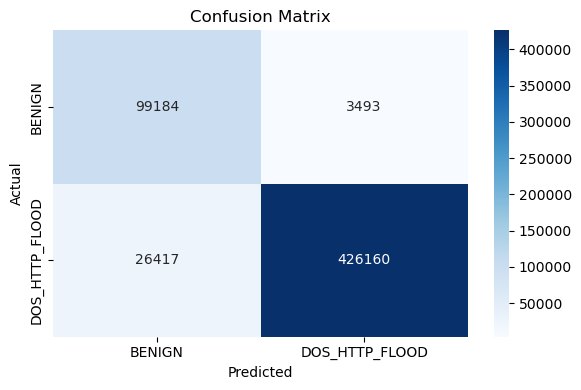

In [18]:
labels = np.unique(np.concatenate([y_true_labels, y_pred_labels]))
cm = confusion_matrix(y_true_labels, y_pred_labels, labels=labels)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [19]:
# Log evaluation metrics to experiment logger
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_true_labels, y_pred_labels)
# Compute macro-averaged metrics
precision = precision_score(y_true_labels, y_pred_labels, average='macro', zero_division=0)
recall = recall_score(y_true_labels, y_pred_labels, average='macro', zero_division=0)
f1 = f1_score(y_true_labels, y_pred_labels, average='macro', zero_division=0)

# Get classification report as dict
class_report = classification_report(y_true_labels, y_pred_labels, digits=4, output_dict=True)

# Compute property loss on test set
model.eval()
prop_losses_test = []
all_stats_test = []

with torch.no_grad():
    for x_batch, _ in test_loader:
        x_batch = x_batch.to(device)
        logits = model(x_batch)
        p_dos = torch.sigmoid(logits)
        prop_loss, stats = properties.compute_loss(model, x_batch, p_dos)
        prop_losses_test.append(prop_loss.item())
        all_stats_test.append(stats)

test_avg_prop_loss = np.mean(prop_losses_test)
test_avg_stats = {k: np.mean([s[k] for s in all_stats_test]) for k in all_stats_test[0].keys()}

# Log evaluation metrics
logger.log_evaluation(
    accuracy=accuracy,
    precision=precision,
    recall=recall,
    f1=f1,
    confusion_matrix=cm,
    classification_report=class_report,
    test_prop_loss=test_avg_prop_loss,
    test_prop_stats=test_avg_stats,
)

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1: {f1:.4f}")
print(f"Test Property Loss: {test_avg_prop_loss:.4f}")
print(f"Test Property Stats: {test_avg_stats}")

# Save experiment results
logger.save_experiment()



Accuracy: 0.9461
Precision: 0.8908
Recall: 0.9538
F1: 0.9175
Test Property Loss: 0.0190
Test Property Stats: {'antecedent': np.float64(0.3870500486968411), 'p_dos': np.float64(0.7774148464861496), 'LowBytes': np.float64(0.42617584443882683), 'LowPackets': np.float64(0.4945233837456115)}

Experiment saved to: ..\experiments\20260403_231021_2props\config_and_results.json


WindowsPath('../experiments/20260403_231021_2props/config_and_results.json')

In [20]:
model.eval()

prop_losses = []
all_stats = []

with torch.no_grad():
    for x_batch, _ in test_loader:
        x_batch = x_batch.to(device)
        logits = model(x_batch)
        p_dos = torch.sigmoid(logits)
        prop_loss, stats = properties.compute_loss(model, x_batch, p_dos)
        prop_losses.append(prop_loss.item())
        all_stats.append(stats)

print("Average property loss:", np.mean(prop_losses))
print("Last batch stats:", all_stats[-1])

Average property loss: 0.019007026457997865
Last batch stats: {'antecedent': 0.3897307217121124, 'p_dos': 0.7887008786201477, 'LowBytes': 0.4291657507419586, 'LowPackets': 0.49596044421195984}


In [21]:
import os
import joblib

os.makedirs("models", exist_ok=True)

save_path = f"models/cnnlstm_property_{Path(DATASET_CSV_PATH).stem}.joblib"

joblib.dump(
    {
        "model": model.cpu(),
        "ordinal_encoder": ordinal_encoder,
        "scaler": scaler,
        "label_encoder": label_encoder,
        "features": FEATURES,
        "categorical_cols": categorical_cols,
    },
    save_path,
)

print("Saved model to:", save_path)
print("Saved encoder n_features_in_:", ordinal_encoder.n_features_in_)

# Print experiment summary
print("\n" + "="*60)
print("EXPERIMENT SUMMARY")
print("="*60)
summary = logger.get_summary()
for key, value in summary.items():
    print(f"{key}: {value}")

Saved model to: models/cnnlstm_property_ciciot2023_labeled_conn.joblib
Saved encoder n_features_in_: 5

EXPERIMENT SUMMARY
experiment_id: 20260403_231021_2props
timestamp: 2026-04-03T23:10:21.574315
num_properties: 2
property_names: ['LowBytes', 'LowPackets']
num_epochs: 10
final_accuracy: 0.9461327608625962
final_f1: 0.9175364117897044
final_pred_loss: 0.08171708504947969
final_prop_loss: 0.046773707305089146
